#Severity modelling

### **Phase 2 (Multi-Speed Severity Classification)**

### Phase 2.1a: Parsing the JSON Structure (Severity Dataset)
Here we load the `.jsonl` files containing the new severity data into a pandas DataFrame. We use regular expressions to parse the filename (e.g., `Bearing_fault_shaftend_10mins_2000rpm_sev1.jsonl`) to automatically extract the `machine_state`, `motor_speed`, and `severity` level, adding them as new columns to our dataset.

In [ ]:
import os
import json
import pandas as pd
import glob
import re
import zipfile

data_source = "/content/final data for severity based modelling.zip"
extract_dir = "/content/extracted_severity_data"

# Extract zip if necessary
if data_source.endswith('.zip'):
    if not os.path.exists(extract_dir):
        print(f"Extracting {data_source}...")
        with zipfile.ZipFile(data_source, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
    # Use recursive glob in case files are inside a nested folder in the zip
    jsonl_files = glob.glob(os.path.join(extract_dir, "**/*.jsonl"), recursive=True)
else:
    jsonl_files = glob.glob(os.path.join(data_source, "*.jsonl"))

all_severity_data = []

for file_path in jsonl_files:
    filename = os.path.basename(file_path)

    # Template: FaultName_Position_Duration_RPM_Severity_Extra.jsonl
    # Example: MechanicalLooseness_Shaftend_10mins_2200rpm_high_360deg.jsonl

    # Use regex to extract the parts safely.
    match = re.search(r'(.+?)_.*?_\d+mins_(\d+rpm)_([a-z0-9]+)_.*\.jsonl$', filename, re.IGNORECASE)

    if match:
        # Group 1: Fault_name, Group 2: motorrpm, Group 3: severitylevel
        state = match.group(1).replace('_', ' ')
        motor_speed = match.group(2).lower()
        severity = match.group(3).lower()
    else:
        # Fallback if a file doesn't perfectly match the new template
        lower_name = filename.lower()
        if '_shaftend' in lower_name:
            state_part = filename[:lower_name.find('_shaftend')]
        elif '_10mins' in lower_name:
            state_part = filename[:lower_name.find('_10mins')]
        else:
            state_part = filename.split('_')[0]

        state = state_part.replace('_', ' ')

        sev_match = re.search(r'_(baseline|low|medium|high|sev\d+)_', lower_name)
        severity = sev_match.group(1) if sev_match else 'unknown'

        rpm_match = re.search(r'(\d+rpm)', lower_name)
        motor_speed = rpm_match.group(1) if rpm_match else 'unknown'

    # Force 'baseline' severity for normal machine state
    if state.lower().strip() == 'normal':
        severity = 'baseline'

    with open(file_path, 'r') as f:
        for line in f:
            try:
                row_data = json.loads(line.strip())
                row_data['machine_state'] = state
                row_data['severity'] = severity
                row_data['motor_speed'] = motor_speed
                all_severity_data.append(row_data)
            except json.JSONDecodeError:
                continue # Skip invalid lines

# Convert to a pandas DataFrame
df_severity = pd.DataFrame(all_severity_data)

print(f"Total rows loaded: {len(df_severity)}")
if not df_severity.empty:
    print(f"Unique Severity Levels Found: {df_severity['severity'].unique()}")
    print(f"Unique Motor Speeds Found: {df_severity['motor_speed'].unique()}")
    display(df_severity.head())
else:
    print("No data found. Please double check the data_source path or the contents of the zip file!")

Extracting /content/final data for severity based modelling.zip...
Total rows loaded: 73363
Unique Severity Levels Found: ['low' 'baseline' 'high' 'medium']
Unique Motor Speeds Found: ['3200rpm' '2200rpm' '2700rpm']


,time,axis,data,machine_state,severity,motor_speed
0,1.777508e+09,X,"[-1827.4140625, -2294.4140625, -2856.4140625, ...",MechanicalLooseness,low,3200rpm
1,1.777508e+09,Y,"[-1112.9248046875, -1045.9248046875, -919.9248...",MechanicalLooseness,low,3200rpm
2,1.777508e+09,Z,"[504.451171875, 917.451171875, 870.451171875, ...",MechanicalLooseness,low,3200rpm
3,1.777508e+09,X,"[0.1884765625, -140.8115234375, -357.811523437...",MechanicalLooseness,low,3200rpm
4,1.777508e+09,Y,"[-2599.3701171875, -2747.3701171875, -2949.370...",MechanicalLooseness,low,3200rpm


In [ ]:
import pandas as pd

# Create a stratified small sample (e.g., 10 rows per combination of state, severity, and speed)
# This ensures your sample has a good mix of all fault types and baselines
df_sample = df_severity.groupby(
    ['machine_state', 'severity', 'motor_speed'],
    group_keys=False
).apply(lambda x: x.sample(min(len(x), 20), random_state=42), include_groups=False).reset_index(drop=True)

# Save the sample to a JSON Lines file to preserve the list arrays in the 'data' column
sample_path = '/content/sample_severity_data.jsonl'
df_sample.to_json(sample_path, orient='records', lines=True)

print(f"Successfully created a sample dataset with {len(df_sample)} rows.")
print(f"Saved to: {sample_path}")

display(df_sample.head())

Successfully created a sample dataset with 600 rows.
Saved to: /content/sample_severity_data.jsonl


,time,axis,data
0,1.777503e+09,Z,"[-44.8076171875, -49.8076171875, -10.807617187..."
1,1.777503e+09,Z,"[140.0654296875, 218.0654296875, 207.065429687..."
2,1.777503e+09,Y,"[-101.2529296875, -101.2529296875, -98.2529296..."
3,1.777503e+09,Z,"[82.7939453125, 20.7939453125, 4.7939453125, 5..."
4,1.777503e+09,X,"[-24.8525390625, -46.8525390625, -33.852539062..."


In [ ]:
import pandas as pd

# Save the dataframes to pickle format to preserve the list/array data types
raw_save_path = '/content/df_severity_raw.pkl'
merged_save_path = '/content/df_severity_merged.pkl'

print("Saving raw extracted dataframe...")
df_severity.to_pickle(raw_save_path)

if 'df_severity_merged' in locals():
    print("Saving synchronized merged dataframe...")
    df_severity_merged.to_pickle(merged_save_path)

print("\n--- Saved Successfully ---")
print(f"Raw Data: {raw_save_path}")
print(f"Merged Data: {merged_save_path}")

Saving raw extracted dataframe...
Saving synchronized merged dataframe...

--- Saved Successfully ---
Raw Data: /content/df_severity_raw.pkl
Merged Data: /content/df_severity_merged.pkl


In [ ]:
# How to load them later (skip the JSON parsing step):
import pandas as pd
df_severity = pd.read_pickle('/content/df_severity_raw.pkl')
df_severity_merged = pd.read_pickle('/content/df_severity_merged.pkl')

### Phase 2.2b: Target Formulation, Context Extraction & Merging
Extract the target variables, perform Speed Context Normalization using a Min-Max Scaler, and merge the X, Y, and Z rows by exact timestamps.

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Speed Context Normalization
# Remove 'rpm' suffix and convert to integer
df_severity['motor_speed_int'] = df_severity['motor_speed'].str.replace('rpm', '').astype(int)
speed_scaler = MinMaxScaler()
df_severity['speed_float'] = speed_scaler.fit_transform(df_severity[['motor_speed_int']])

merged_severity_records = []

# Process independent groups
for (state, sev, speed_flt, speed_int), group_df in df_severity.groupby(['machine_state', 'severity', 'speed_float', 'motor_speed_int']):
    group_df = group_df.sort_values('time')

    buffer = {}
    expected_axis = 'X'
    group_time = None

    for _, row in group_df.iterrows():
        axis = row['axis']
        wave = row['data']
        row_time = row['time']

        if axis == 'X' and expected_axis == 'X':
            buffer['X'] = wave
            group_time = row_time
            expected_axis = 'Y'
        elif axis == 'Y' and expected_axis == 'Y':
            buffer['Y'] = wave
            expected_axis = 'Z'
        elif axis == 'Z' and expected_axis == 'Z':
            buffer['Z'] = wave
            merged_severity_records.append({
                'time': group_time,
                'machine_state': state,
                'severity': sev,
                'speed_float': speed_flt,
                'motor_speed_int': speed_int,
                'X': buffer['X'],
                'Y': buffer['Y'],
                'Z': buffer['Z']
            })
            buffer = {}
            expected_axis = 'X'
        else:
            if axis == 'X':
                buffer = {'X': wave}
                group_time = row_time
                expected_axis = 'Y'
            else:
                buffer = {}
                expected_axis = 'X'

df_severity_merged = pd.DataFrame(merged_severity_records)
print(f"Total synchronized samples: {len(df_severity_merged)}")
display(df_severity_merged.head())

Total synchronized samples: 21596


,time,machine_state,severity,speed_float,motor_speed_int,X,Y,Z
0,1.777503e+09,MechanicalLooseness,high,0.0,2200,"[2.7802734375, 6.7802734375, 23.7802734375, 13...","[6.1435546875, 8.1435546875, 15.1435546875, 7....","[-16.3046875, 29.6953125, 70.6953125, 51.69531..."
1,1.777503e+09,MechanicalLooseness,high,0.0,2200,"[-57.8505859375, -59.8505859375, -82.850585937...","[-126.9140625, -139.9140625, -136.9140625, -14...","[57.2138671875, 63.2138671875, 52.2138671875, ..."
2,1.777503e+09,MechanicalLooseness,high,0.0,2200,"[35.51953125, 32.51953125, 31.51953125, 33.519...","[-11.4423828125, -12.4423828125, -7.4423828125...","[46.4111328125, 55.4111328125, 37.4111328125, ..."
3,1.777503e+09,MechanicalLooseness,high,0.0,2200,"[-40.9501953125, -30.9501953125, -34.950195312...","[-140.48828125, -142.48828125, -134.48828125, ...","[63.29296875, 51.29296875, 33.29296875, 24.292..."
4,1.777503e+09,MechanicalLooseness,high,0.0,2200,"[59.89453125, 66.89453125, 78.89453125, 67.894...","[135.0400390625, 139.0400390625, 136.040039062...","[-20.4296875, -30.4296875, -37.4296875, -40.42..."


### Phase 2.3a: Tensor Reshaping & Global Scaling
Here we stack the synchronized time-series data into 3D NumPy arrays. We then apply a Global Maximum Scaler across the entire dataset to preserve the physical amplitude differences between minor and critical faults. After scaling, we perform a stratified Train/Validation/Test split and finally convert the scaled time-domain tensors into frequency-domain (FFT) tensors.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# 1. Tensor Generation & Speed Extraction
X_sev = np.array(df_severity_merged['X'].tolist())
Y_sev = np.array(df_severity_merged['Y'].tolist())
Z_sev = np.array(df_severity_merged['Z'].tolist())

tensors_sev = np.stack((X_sev, Y_sev, Z_sev), axis=1)
speeds_float = df_severity_merged['speed_float'].values
raw_speeds = df_severity_merged['motor_speed_int'].values

# 2. Variable Extraction & One-Hot Encoding
encoder_state = LabelEncoder()
encoded_states = encoder_state.fit_transform(df_severity_merged['machine_state'])
cat_states = to_categorical(encoded_states)

encoder_sev = LabelEncoder()
# Define explicit order for severities just in case
severity_classes = ['baseline', 'low', 'medium', 'high']
encoder_sev.fit(severity_classes)
encoded_severities = encoder_sev.transform(df_severity_merged['severity'])
cat_severities = to_categorical(encoded_severities, num_classes=4)

# 3. Global Scaling
global_max = np.max(np.abs(tensors_sev))
tensors_sev_scaled = tensors_sev / global_max

# Generate stratification labels
combined_labels = [f"{st}_{sv}_{sp}" for st, sv, sp in zip(encoded_states, encoded_severities, raw_speeds)]

try:
    # 4. Multi-Level Split
    indices = np.arange(len(tensors_sev_scaled))
    idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42, stratify=combined_labels)
    idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)
except ValueError:
    print("Stratification failed due to dummy class counts. Splitting without stratification.")
    indices = np.arange(len(tensors_sev_scaled))
    idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42)
    idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

# Split Data
X_train = np.transpose(tensors_sev_scaled[idx_train], (0, 2, 1))
X_val = np.transpose(tensors_sev_scaled[idx_val], (0, 2, 1))
X_test = np.transpose(tensors_sev_scaled[idx_test], (0, 2, 1))

speed_train = speeds_float[idx_train]
speed_val = speeds_float[idx_val]
speed_test = speeds_float[idx_test]

y_state_train = cat_states[idx_train]
y_state_val = cat_states[idx_val]
y_state_test = cat_states[idx_test]

y_sev_train = cat_severities[idx_train]
y_sev_val = cat_severities[idx_val]
y_sev_test = cat_severities[idx_test]

# 5. FFT Transformation
X_train_fft = np.log1p(np.abs(np.fft.rfft(X_train, axis=1)))
X_val_fft = np.log1p(np.abs(np.fft.rfft(X_val, axis=1)))
X_test_fft = np.log1p(np.abs(np.fft.rfft(X_test, axis=1)))

print(f"Training set (FFT): {X_train_fft.shape}")

Training set (FFT): (15117, 513, 3)


## Phase 2.4a: Dual-Head CNN Architecture


Construct a network with a shared 1D-CNN feature extractor branching into a Softmax head and a Softmax head, and train it on the actual data.


#### CNN model - v1

In [ ]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Activation, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Input A: FFT Data
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]
input_fft = Input(shape=(freq_bins, channels), name='fft_input')

x = Conv1D(filters=32, kernel_size=8, padding='same')(input_fft)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(filters=64, kernel_size=4, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(pool_size=2)(x)

cnn_features = GlobalAveragePooling1D()(x)

# Input B: Speed Float Context
input_speed = Input(shape=(1,), name='speed_input')
speed_features = Dense(8, activation='relu')(input_speed)

# Fusion Layer
merged = Concatenate()([cnn_features, speed_features])
merged = Dense(64, activation='relu')(merged)
shared_features = Dropout(0.3)(merged)

# Dual Softmax Heads
num_state_classes = y_state_train.shape[1]
state_output = Dense(num_state_classes, activation='softmax', name='state_output')(shared_features)

num_sev_classes = y_sev_train.shape[1]
severity_output = Dense(num_sev_classes, activation='softmax', name='severity_output')(shared_features)

# Model Compilation
multi_input_model = Model(inputs=[input_fft, input_speed], outputs=[state_output, severity_output])

multi_input_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'state_output': 'categorical_crossentropy',
        'severity_output': 'categorical_crossentropy'
    },
    metrics={'state_output': 'accuracy', 'severity_output': 'accuracy'}
)

multi_input_model.summary()

# Train the Model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nTraining Multi-Input Dual-Head Model...")
history_multi = multi_input_model.fit(
    {'fft_input': X_train_fft, 'speed_input': speed_train},
    {'state_output': y_state_train, 'severity_output': y_sev_train},
    epochs=25,
    batch_size=8,
    validation_data=(
        {'fft_input': X_val_fft, 'speed_input': speed_val},
        {'state_output': y_state_val, 'severity_output': y_sev_val}
    ),
    callbacks=[early_stop],
    verbose=1
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fft_input           │ (None, 513, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 513, 32)   │        800 │ fft_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 513, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 513, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 256, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 64)   │      8,256 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 128, 64)   │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ speed_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling1d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         16 │ speed_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,672 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_output        │ (None, 4)         │        260 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_output     │ (None, 4)         │        260 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,648 (57.22 KB)

 Trainable params: 14,456 (56.47 KB)

 Non-trainable params: 192 (768.00 B)


Training Multi-Input Dual-Head Model...
Epoch 1/25
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 2.4609 - severity_output_accuracy: 0.3365 - severity_output_loss: 1.3010 - state_output_accuracy: 0.4738 - state_output_loss: 1.1600 - val_loss: 3.1743 - val_severity_output_accuracy: 0.3066 - val_severity_output_loss: 1.3937 - val_state_output_accuracy: 0.3279 - val_state_output_loss: 1.7803
Epoch 2/25
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.3040 - severity_output_accuracy: 0.3378 - severity_output_loss: 1.2685 - state_output_accuracy: 0.5344 - state_output_loss: 1.0355 - val_loss: 2.8418 - val_severity_output_accuracy: 0.2634 - val_severity_output_loss: 1.4528 - val_state_output_accuracy: 0.3325 - val_state_output_loss: 1.3889
Epoch 3/25
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.1990 - severity_output_accuracy: 0.3543 - severity_output_loss: 1.2480 - state_output_accuracy: 0.5846 - state_output_loss: 0.9510 - val_loss: 11.5059 - val_severity_output_accuracy:

#### CNN model - v2

In [ ]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Activation, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Input A: FFT Data
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]
input_fft = Input(shape=(freq_bins, channels), name='fft_input')

# Deeper CNN Architecture
x = Conv1D(filters=64, kernel_size=7, padding='same')(input_fft)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)

x = Conv1D(filters=128, kernel_size=5, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)

x = Conv1D(filters=256, kernel_size=3, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
cnn_features = GlobalAveragePooling1D()(x)

# Input B: Speed Float Context
input_speed = Input(shape=(1,), name='speed_input')
speed_features = Dense(16, activation='relu')(input_speed)

# Fusion Layer
merged = Concatenate()([cnn_features, speed_features])
merged = Dense(128, activation='relu')(merged)
shared_features = Dropout(0.4)(merged)

# Dual Softmax Heads
num_state_classes = y_state_train.shape[1]
state_output = Dense(num_state_classes, activation='softmax', name='state_output')(shared_features)

num_sev_classes = y_sev_train.shape[1]
severity_output = Dense(num_sev_classes, activation='softmax', name='severity_output')(shared_features)

# Model Compilation
alt_model = Model(inputs=[input_fft, input_speed], outputs=[state_output, severity_output])

alt_model.compile(
    optimizer=Adam(learning_rate=0.0005), # Lower learning rate for stability
    loss={
        'state_output': 'categorical_crossentropy',
        'severity_output': 'categorical_crossentropy'
    },
    metrics={'state_output': 'accuracy', 'severity_output': 'accuracy'}
)

alt_model.summary()

# Train the Model
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("\nTraining Alternative Architecture (Deeper CNN)...")
history_alt = alt_model.fit(
    {'fft_input': X_train_fft, 'speed_input': speed_train},
    {'state_output': y_state_train, 'severity_output': y_sev_train},
    epochs=30,
    batch_size=16,
    validation_data=(
        {'fft_input': X_val_fft, 'speed_input': speed_val},
        {'state_output': y_state_val, 'severity_output': y_sev_val}
    ),
    callbacks=[early_stop],
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fft_input           │ (None, 513, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 513, 64)   │      1,408 │ fft_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 513, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 256, 64)   │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 64)   │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 256, 128)  │     41,088 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 128, 128)  │          0 │ activation_3[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 128)  │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 256)  │     98,560 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256)  │      1,024 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 128, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ speed_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ activation_4[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │         32 │ speed_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 272)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     34,944 │ concatenate_1[0]

 Total params: 178,856 (698.66 KB)

 Trainable params: 177,960 (695.16 KB)

 Non-trainable params: 896 (3.50 KB)


Training Alternative Architecture (Deeper CNN)...
Epoch 1/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 2.5540 - severity_output_accuracy: 0.3285 - severity_output_loss: 1.3240 - state_output_accuracy: 0.4470 - state_output_loss: 1.2300 - val_loss: 3.5285 - val_severity_output_accuracy: 0.3226 - val_severity_output_loss: 1.4215 - val_state_output_accuracy: 0.3307 - val_state_output_loss: 2.1027
Epoch 2/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.3492 - severity_output_accuracy: 0.3556 - severity_output_loss: 1.2808 - state_output_accuracy: 0.5268 - state_output_loss: 1.0683 - val_loss: 15.5225 - val_severity_output_accuracy: 0.2630 - val_severity_output_loss: 2.8600 - val_state_output_accuracy: 0.3310 - val_state_output_loss: 12.6359
Epoch 3/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.1509 - severity_output_accuracy: 0.3970 - severity_output_loss: 1.2203 - state_output_accuracy: 0.5991 - state_output_loss: 0.9304 - val_loss: 42.8730 - val_severity_output_ac

#### CNN model - v3

In [ ]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, Activation, Concatenate, Bidirectional, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Input A: FFT Data
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]
input_fft = Input(shape=(freq_bins, channels), name='fft_input')

# CNN Feature Extraction
x = Conv1D(filters=64, kernel_size=5, padding='same')(input_fft)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(filters=128, kernel_size=3, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling1D(pool_size=2)(x)

# Sequence Modeling with BiLSTM
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Bidirectional(LSTM(32))(x)
x = Dropout(0.3)(x)

# Input B: Speed Float Context
input_speed = Input(shape=(1,), name='speed_input')
speed_features = Dense(16, activation='relu')(input_speed)

# Fusion Layer
merged = Concatenate()([x, speed_features])
merged = Dense(128, activation='relu')(merged)
shared_features = Dropout(0.4)(merged)

# Dual Softmax Heads
num_state_classes = y_state_train.shape[1]
state_output = Dense(num_state_classes, activation='softmax', name='state_output')(shared_features)

num_sev_classes = y_sev_train.shape[1]
severity_output = Dense(num_sev_classes, activation='softmax', name='severity_output')(shared_features)

# Model Compilation
rnn_model = Model(inputs=[input_fft, input_speed], outputs=[state_output, severity_output])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss={
        'state_output': 'categorical_crossentropy',
        'severity_output': 'categorical_crossentropy'
    },
    metrics={'state_output': 'accuracy', 'severity_output': 'accuracy'}
)

rnn_model.summary()

# Train the Model
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("\nTraining Hybrid CNN-BiLSTM Architecture...")
history_rnn = rnn_model.fit(
    {'fft_input': X_train_fft, 'speed_input': speed_train},
    {'state_output': y_state_train, 'severity_output': y_sev_train},
    epochs=30,
    batch_size=16,
    validation_data=(
        {'fft_input': X_val_fft, 'speed_input': speed_val},
        {'state_output': y_state_val, 'severity_output': y_sev_val}
    ),
    callbacks=[early_stop],
    verbose=1
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fft_input           │ (None, 513, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 513, 64)   │      1,024 │ fft_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 64)   │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 513, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 256, 64)   │          0 │ activation_5[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 256, 128)  │     24,704 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 256, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 128, 128)  │          0 │ activation_6[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128, 128)  │     98,816 │ max_pooling1d_5[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ speed_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │         32 │ speed_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 80)        │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     10,368 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_output        │ (None, 4)         │        516 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_output     │ (None, 4)         │        516 │ dropout_5[0][0] 

 Total params: 177,960 (695.16 KB)

 Trainable params: 177,576 (693.66 KB)

 Non-trainable params: 384 (1.50 KB)


Training Hybrid CNN-BiLSTM Architecture...
Epoch 1/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - loss: 2.3359 - severity_output_accuracy: 0.3658 - severity_output_loss: 1.2457 - state_output_accuracy: 0.5133 - state_output_loss: 1.0901 - val_loss: 4.2404 - val_severity_output_accuracy: 0.3223 - val_severity_output_loss: 1.6137 - val_state_output_accuracy: 0.3313 - val_state_output_loss: 2.6210
Epoch 2/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - loss: 1.7021 - severity_output_accuracy: 0.4729 - severity_output_loss: 1.0560 - state_output_accuracy: 0.7295 - state_output_loss: 0.6459 - val_loss: 5.9995 - val_severity_output_accuracy: 0.3208 - val_severity_output_loss: 1.8941 - val_state_output_accuracy: 0.3307 - val_state_output_loss: 4.0960
Epoch 3/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - loss: 1.2958 - severity_output_accuracy: 0.5924 - severity_output_loss: 0.8641 - state_output_accuracy: 0.8142 - state_output_loss: 0.4317 - val_loss: 2.8151 - val_severity_output_accuracy

#### CNN model - v4

In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Input A: FFT Data
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]
input_fft = Input(shape=(freq_bins, channels), name='fft_input')

# Transformer Block (Self-Attention)
attention_output = MultiHeadAttention(num_heads=4, key_dim=64)(input_fft, input_fft)
attention_output = Dropout(0.2)(attention_output)
out1 = LayerNormalization(epsilon=1e-6)(input_fft + attention_output)

# Feed Forward Network inside Transformer
ffn_output = Dense(128, activation='relu')(out1)
ffn_output = Dense(channels)(ffn_output)
ffn_output = Dropout(0.2)(ffn_output)
transformer_features = LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

# Pooling
x = GlobalAveragePooling1D()(transformer_features)

# Input B: Speed Float Context
input_speed = Input(shape=(1,), name='speed_input')
speed_features = Dense(16, activation='relu')(input_speed)

# Fusion Layer
merged = Concatenate()([x, speed_features])
merged = Dense(64, activation='relu')(merged)
shared_features = Dropout(0.3)(merged)

# Dual Softmax Heads
num_state_classes = y_state_train.shape[1]
state_output = Dense(num_state_classes, activation='softmax', name='state_output')(shared_features)

num_sev_classes = y_sev_train.shape[1]
severity_output = Dense(num_sev_classes, activation='softmax', name='severity_output')(shared_features)

# Model Compilation
transformer_model = Model(inputs=[input_fft, input_speed], outputs=[state_output, severity_output])

transformer_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss={
        'state_output': 'categorical_crossentropy',
        'severity_output': 'categorical_crossentropy'
    },
    metrics={'state_output': 'accuracy', 'severity_output': 'accuracy'}
)

transformer_model.summary()

# Train the Model
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("\nTraining Transformer Architecture...")
history_transformer = transformer_model.fit(
    {'fft_input': X_train_fft, 'speed_input': speed_train},
    {'state_output': y_state_train, 'severity_output': y_sev_train},
    epochs=30,
    batch_size=16,
    validation_data=(
        {'fft_input': X_val_fft, 'speed_input': speed_val},
        {'state_output': y_state_val, 'severity_output': y_sev_val}
    ),
    callbacks=[early_stop],
    verbose=1
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fft_input           │ (None, 513, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 513, 3)    │      3,843 │ fft_input[0][0],  │
│ (MultiHeadAttentio… │                   │            │ fft_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 513, 3)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 513, 3)    │          0 │ fft_input[0][0],  │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 513, 3)    │          6 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 513, 128)  │        512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 513, 3)    │        387 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 513, 3)    │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 513, 3)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 513, 3)    │          6 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ speed_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 3)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │         32 │ speed_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 19)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      1,280 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_output        │ (None, 4)         │        260 │ dropout_9[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_output     │ (None, 4)         │        260 │ dropout_9[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,586 (25.73 KB)

 Trainable params: 6,586 (25.73 KB)

 Non-trainable params: 0 (0.00 B)


Training Transformer Architecture...
Epoch 1/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 2.6613 - severity_output_accuracy: 0.3042 - severity_output_loss: 1.3318 - state_output_accuracy: 0.3214 - state_output_loss: 1.3295 - val_loss: 2.6446 - val_severity_output_accuracy: 0.3192 - val_severity_output_loss: 1.3254 - val_state_output_accuracy: 0.3266 - val_state_output_loss: 1.3185
Epoch 2/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.6437 - severity_output_accuracy: 0.3153 - severity_output_loss: 1.3230 - state_output_accuracy: 0.3263 - state_output_loss: 1.3207 - val_loss: 2.6420 - val_severity_output_accuracy: 0.3220 - val_severity_output_loss: 1.3245 - val_state_output_accuracy: 0.3316 - val_state_output_loss: 1.3167
Epoch 3/30
945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.6382 - severity_output_accuracy: 0.3200 - severity_output_loss: 1.3211 - state_output_accuracy: 0.3209 - state_output_loss: 1.3172 - val_loss: 2.6464 - val_severity_output_accuracy: 0.3186 -

#### MiniRocket + Ridge Model

In [ ]:
!pip install -q sktime

import numpy as np
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score

# 1. Prepare Multivariate Time-Domain Data
# sktime expects shape (samples, channels, timepoints)
# X_train is currently (N, 1024, 3) from the Keras prep step, so we transpose back to (N, 3, 1024).
X_train_time = np.transpose(X_train, (0, 2, 1))
X_val_time = np.transpose(X_val, (0, 2, 1))
X_test_time = np.transpose(X_test, (0, 2, 1))

# 2. Fit and Transform with MiniRocketMultivariate
print("Fitting MiniRocketMultivariate on Time-Domain Data (this may take a moment)...")
minirocket = MiniRocketMultivariate()
X_train_features = minirocket.fit_transform(X_train_time)
X_val_features = minirocket.transform(X_val_time)
X_test_features = minirocket.transform(X_test_time)

# 3. Context Fusion (Append Speed Float)
print("Fusing MiniRocket features with Speed Context...")
X_train_fused = np.hstack((X_train_features, speed_train.reshape(-1, 1)))
X_val_fused = np.hstack((X_val_features, speed_val.reshape(-1, 1)))
X_test_fused = np.hstack((X_test_features, speed_test.reshape(-1, 1)))

# 4. Target Conversion
# RidgeClassifier expects 1D arrays (class indices), not one-hot encoded vectors.
y_state_train_1d = np.argmax(y_state_train, axis=1)
y_sev_train_1d = np.argmax(y_sev_train, axis=1)
y_state_val_1d = np.argmax(y_state_val, axis=1)
y_sev_val_1d = np.argmax(y_sev_val, axis=1)

# 5. Dual Classification with Ridge Regression
print("Training Classifier 1: Machine State...")
clf_state = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
clf_state.fit(X_train_fused, y_state_train_1d)

print("Training Classifier 2: Ordinal Severity...")
clf_sev = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
clf_sev.fit(X_train_fused, y_sev_train_1d)

# Evaluation on Validation Set
state_val_preds = clf_state.predict(X_val_fused)
sev_val_preds = clf_sev.predict(X_val_fused)

print(f"\nValidation Accuracy - Machine State: {accuracy_score(y_state_val_1d, state_val_preds):.4f}")
print(f"Validation Accuracy - Ordinal Severity: {accuracy_score(y_sev_val_1d, sev_val_preds):.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 18.3 MB/s eta 0:00:00
Fitting MiniRocketMultivariate on Time-Domain Data (this may take a moment)...
Fusing MiniRocket features with Speed Context...
Training Classifier 1: Machine State...
Training Classifier 2: Ordinal Severity...

Validation Accuracy - Machine State: 0.9966
Validation Accuracy - Ordinal Severity: 0.9895


--- Head 1: Machine State Classification (MiniRocket) ---
                     precision    recall  f1-score   support

MechanicalLooseness       1.00      1.00      1.00       832
       Misalignment       1.00      1.00      1.00      1030
             Normal       0.99      0.99      0.99       329
          Unbalance       1.00      0.99      1.00      1049

           accuracy                           1.00      3240
          macro avg       1.00      1.00      1.00      3240
       weighted avg       1.00      1.00      1.00      3240


--- Head 2: Ordinal Severity Classification (MiniRocket) ---
              precision    recall  f1-score   support

    baseline       0.99      0.99      0.99       329
        high       0.99      0.99      0.99       866
         low       0.99      0.98      0.99      1010
      medium       0.99      0.99      0.99      1035

    accuracy                           0.99      3240
   macro avg       0.99      0.99      0.99      3240
weighted 

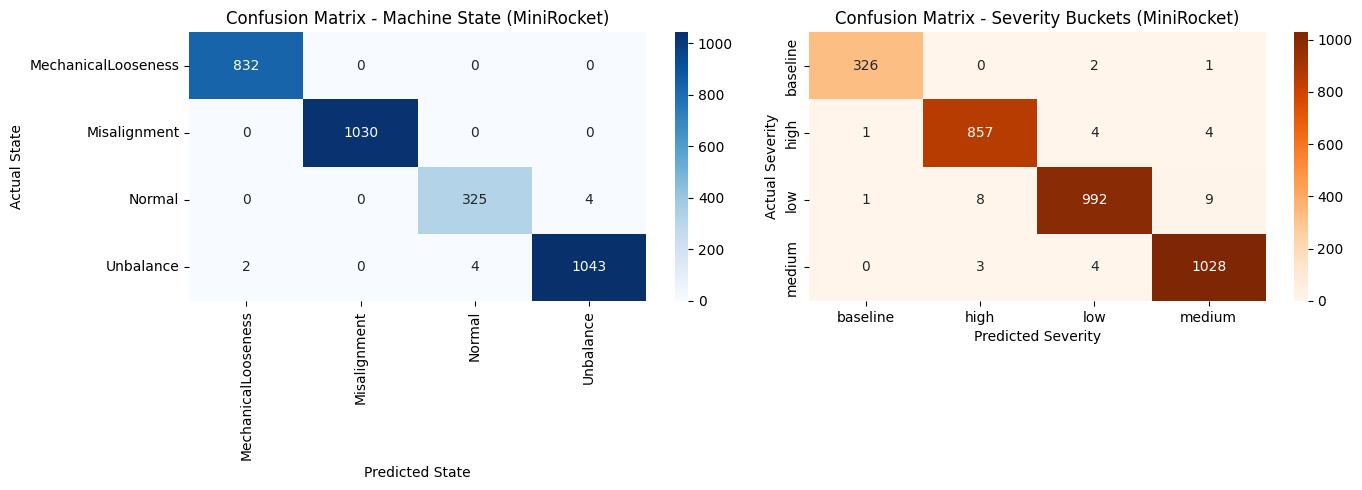

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Target Conversion for Test Set
y_state_test_1d = np.argmax(y_state_test, axis=1)
y_sev_test_1d = np.argmax(y_sev_test, axis=1)

# 2. Predict on Test Set
state_test_preds = clf_state.predict(X_test_fused)
sev_test_preds = clf_sev.predict(X_test_fused)

# 3. Detailed Metrics (Classification Reports)
print("--- Head 1: Machine State Classification (MiniRocket) ---")
print(classification_report(y_state_test_1d, state_test_preds, target_names=encoder_state.classes_, zero_division=0))

print("\n--- Head 2: Ordinal Severity Classification (MiniRocket) ---")
print(classification_report(y_sev_test_1d, sev_test_preds, target_names=encoder_sev.classes_, zero_division=0))

# 4. Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_state = confusion_matrix(y_state_test_1d, state_test_preds)
sns.heatmap(cm_state, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=encoder_state.classes_, yticklabels=encoder_state.classes_)
axes[0].set_title('Confusion Matrix - Machine State (MiniRocket)')
axes[0].set_ylabel('Actual State')
axes[0].set_xlabel('Predicted State')

cm_sev = confusion_matrix(y_sev_test_1d, sev_test_preds)
sns.heatmap(cm_sev, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=encoder_sev.classes_, yticklabels=encoder_sev.classes_)
axes[1].set_title('Confusion Matrix - Severity Buckets (MiniRocket)')
axes[1].set_ylabel('Actual Severity')
axes[1].set_xlabel('Predicted Severity')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Cross-Speed Validation for MiniRocket
print("\n--- Cross-Speed Validation on Test Set (MiniRocket) ---")
raw_test_speeds = raw_speeds[idx_test]
for target_speed in [2200, 2700, 3200]:
    speed_mask = raw_test_speeds == target_speed
    if np.sum(speed_mask) > 0:
        acc_state = np.mean(state_test_preds[speed_mask] == y_state_test_1d[speed_mask])
        acc_sev = np.mean(sev_test_preds[speed_mask] == y_sev_test_1d[speed_mask])
        print(f"RPM: {target_speed} | Samples: {np.sum(speed_mask)} | State Acc: {acc_state:.4f} | Severity Acc: {acc_sev:.4f}")
    else:
        print(f"RPM: {target_speed} | No samples in test set.")


--- Cross-Speed Validation on Test Set (MiniRocket) ---
RPM: 2200 | Samples: 1073 | State Acc: 0.9981 | Severity Acc: 0.9925
RPM: 2700 | Samples: 1089 | State Acc: 0.9927 | Severity Acc: 0.9761
RPM: 3200 | Samples: 1078 | State Acc: 1.0000 | Severity Acc: 0.9972


In [ ]:
import joblib

# Group all necessary components for deployment into a single dictionary
minirocket_pipeline = {
    'minirocket': minirocket,
    'clf_state': clf_state,
    'clf_sev': clf_sev,
    'speed_scaler': speed_scaler,
    'encoder_state': encoder_state,
    'encoder_sev': encoder_sev,
    'global_max': global_max
}

# Save the pipeline to disk
save_path = '/content/minirocket_pipeline.joblib'
joblib.dump(minirocket_pipeline, save_path)

print(f"MiniRocket pipeline and associated objects successfully saved to: {save_path}")
print("To load it later, you can use:")
print("loaded_pipeline = joblib.load('/content/minirocket_pipeline.joblib')")

MiniRocket pipeline and associated objects successfully saved to: /content/minirocket_pipeline.joblib
To load it later, you can use:
loaded_pipeline = joblib.load('/content/minirocket_pipeline.joblib')


#### CNN model - v

In [ ]:
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense, BatchNormalization, Activation, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# We use the raw time-domain data directly!
# X_train is already shape (N, 1024, 3)
time_steps = X_train.shape[1]
channels = X_train.shape[2]

# Input A: Raw Time-Domain Tensor
input_time = Input(shape=(time_steps, channels), name='time_input')

# FCN Block 1
x = Conv1D(filters=128, kernel_size=8, padding='same')(input_time)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# FCN Block 2
x = Conv1D(filters=256, kernel_size=5, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# FCN Block 3
x = Conv1D(filters=128, kernel_size=3, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# Global Pooling
cnn_features = GlobalAveragePooling1D()(x)

# Input B: Speed Context
input_speed = Input(shape=(1,), name='speed_input')
speed_features = Dense(16, activation='relu')(input_speed)

# Feature Fusion
merged = Concatenate()([cnn_features, speed_features])
merged = Dense(128, activation='relu')(merged)
shared_features = Dropout(0.3)(merged)

# Dual Heads
num_state_classes = y_state_train.shape[1]
state_output = Dense(num_state_classes, activation='softmax', name='state_output')(shared_features)

num_sev_classes = y_sev_train.shape[1]
severity_output = Dense(num_sev_classes, activation='softmax', name='severity_output')(shared_features)

# Build and Compile
fcn_model = Model(inputs=[input_time, input_speed], outputs=[state_output, severity_output])

fcn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'state_output': 'categorical_crossentropy',
        'severity_output': 'categorical_crossentropy'
    },
    metrics={'state_output': 'accuracy', 'severity_output': 'accuracy'}
)

fcn_model.summary()

# Callbacks to stabilize training
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

print("\nTraining Time-Domain FCN Dual-Head Model...")
history_fcn = fcn_model.fit(
    {'time_input': X_train, 'speed_input': speed_train},
    {'state_output': y_state_train, 'severity_output': y_sev_train},
    epochs=40,
    batch_size=64, # Larger batch size for stable BatchNorm
    validation_data=(
        {'time_input': X_val, 'speed_input': speed_val},
        {'state_output': y_state_val, 'severity_output': y_sev_val}
    ),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_input          │ (None, 1024, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 1024, 128) │      3,200 │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 1024, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 1024, 256) │    164,096 │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 256) │      1,024 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 1024, 256) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 1024, 128) │     98,432 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 1024, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ speed_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_9[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │         32 │ speed_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 144)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │     18,560 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_output        │ (None, 4)         │        516 │ dropout_10[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_output     │ (None, 4)         │        516 │ dropout_10[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 287,400 (1.10 MB)

 Trainable params: 286,376 (1.09 MB)

 Non-trainable params: 1,024 (4.00 KB)


Training Time-Domain FCN Dual-Head Model...
Epoch 1/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - loss: 2.5370 - severity_output_accuracy: 0.3361 - severity_output_loss: 1.3080 - state_output_accuracy: 0.4341 - state_output_loss: 1.2286 - val_loss: 2.7810 - val_severity_output_accuracy: 0.2634 - val_severity_output_loss: 1.3771 - val_state_output_accuracy: 0.2887 - val_state_output_loss: 1.4026 - learning_rate: 0.0010
Epoch 2/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.3775 - severity_output_accuracy: 0.3631 - severity_output_loss: 1.2703 - state_output_accuracy: 0.4967 - state_output_loss: 1.1063 - val_loss: 3.3572 - val_severity_output_accuracy: 0.2634 - val_severity_output_loss: 1.5717 - val_state_output_accuracy: 0.3300 - val_state_output_loss: 1.7822 - learning_rate: 0.0010
Epoch 3/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.2795 - severity_output_accuracy: 0.3762 - severity_output_loss: 1.2425 - state_output_accuracy: 0.5311 - state_output_loss: 1.0369 - va

## Evaluate Dual-Head Model

Evaluate the dual-head model on the test set by computing classification metrics (Precision, Recall, F1-Score) and regression metrics (MAE, RMSE, R-Squared), and displaying a confusion matrix and a regression scatter plot.


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
--- Head 1: Machine State Classification ---
                     precision    recall  f1-score   support

MechanicalLooseness       0.50      0.01      0.01       832
       Misalignment       0.32      1.00      0.48      1030
             Normal       1.00      0.00      0.01       329
          Unbalance       0.00      0.00      0.00      1049

           accuracy                           0.32      3240
          macro avg       0.45      0.25      0.13      3240
       weighted avg       0.33      0.32      0.16      3240


--- Head 2: Ordinal Severity Classification ---
              precision    recall  f1-score   support

    baseline       0.00      0.00      0.00       329
        high       0.27      1.00      0.42       866
         low       0.00      0.00      0.00      1010
      medium       0.00      0.00      0.00      1035

    accuracy                           0.27      3240
   macro avg       0.07      0.25      0.11     

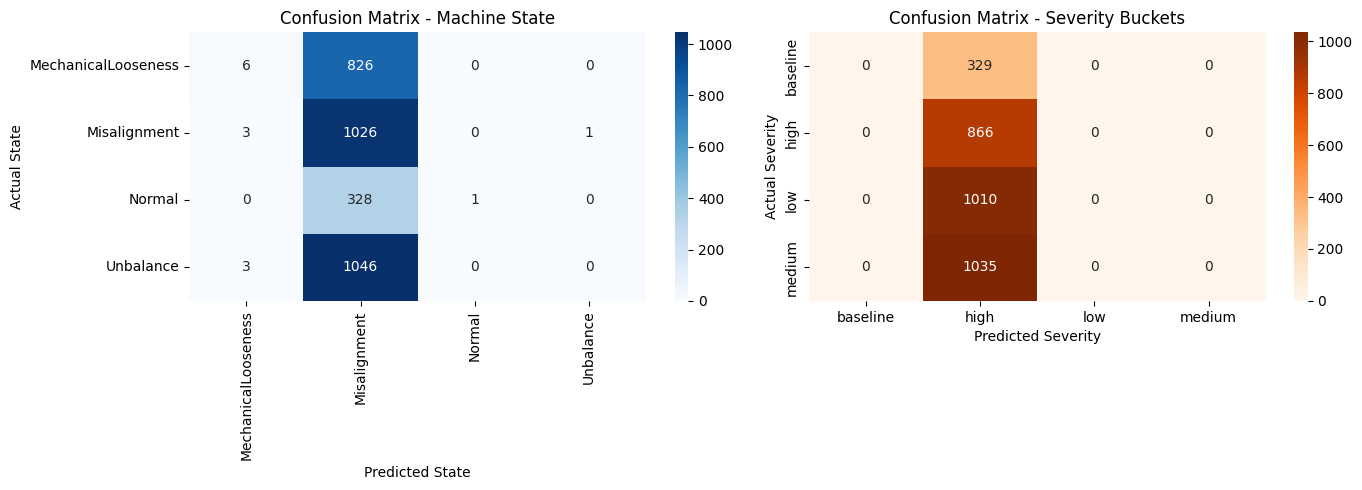


--- Cross-Speed Validation on Test Set ---
RPM: 2200 | Samples: 1073 | State Acc: 0.32 | Severity Acc: 0.29
RPM: 2700 | Samples: 1089 | State Acc: 0.35 | Severity Acc: 0.25
RPM: 3200 | Samples: 1078 | State Acc: 0.29 | Severity Acc: 0.27


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Predict on the test set
pred_probs_state, pred_probs_sev = multi_input_model.predict({'fft_input': X_test_fft, 'speed_input': speed_test})

pred_state_classes = np.argmax(pred_probs_state, axis=1)
pred_sev_classes = np.argmax(pred_probs_sev, axis=1)

true_state_classes = np.argmax(y_state_test, axis=1)
true_sev_classes = np.argmax(y_sev_test, axis=1)

print("--- Head 1: Machine State Classification ---")
print(classification_report(true_state_classes, pred_state_classes, target_names=encoder_state.classes_, zero_division=0))

print("\n--- Head 2: Ordinal Severity Classification ---")
print(classification_report(true_sev_classes, pred_sev_classes, target_names=encoder_sev.classes_, zero_division=0))

# Plotting Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_state = confusion_matrix(true_state_classes, pred_state_classes)
sns.heatmap(cm_state, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=encoder_state.classes_, yticklabels=encoder_state.classes_)
axes[0].set_title('Confusion Matrix - Machine State')
axes[0].set_ylabel('Actual State')
axes[0].set_xlabel('Predicted State')

cm_sev = confusion_matrix(true_sev_classes, pred_sev_classes)
sns.heatmap(cm_sev, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=encoder_sev.classes_, yticklabels=encoder_sev.classes_)
axes[1].set_title('Confusion Matrix - Severity Buckets')
axes[1].set_ylabel('Actual Severity')
axes[1].set_xlabel('Predicted Severity')

plt.tight_layout()
plt.show()

# Cross-Speed Validation
print("\n--- Cross-Speed Validation on Test Set ---")
raw_test_speeds = raw_speeds[idx_test]
for target_speed in [2200, 2700, 3200]:
    speed_mask = raw_test_speeds == target_speed
    if np.sum(speed_mask) > 0:
        acc_state = np.mean(pred_state_classes[speed_mask] == true_state_classes[speed_mask])
        acc_sev = np.mean(pred_sev_classes[speed_mask] == true_sev_classes[speed_mask])
        print(f"RPM: {target_speed} | Samples: {np.sum(speed_mask)} | State Acc: {acc_state:.2f} | Severity Acc: {acc_sev:.2f}")
    else:
        print(f"RPM: {target_speed} | No samples in test set.")

## Deployment Simulation

Create a deployment simulation pipeline that processes raw dummy sensor data, predicts the machine state and continuous severity using the dual-head model, and maps the severity output to ISO 20816-3 Action Zones to trigger simulated maintenance alerts.


In [ ]:
import numpy as np
import tensorflow as tf

def simulate_deployment_multi(x_data, y_data, z_data, raw_speed):
    # 1. Processing Tensors
    raw_tensor = np.stack((x_data, y_data, z_data), axis=0)
    raw_tensor = np.expand_dims(raw_tensor, axis=0)
    scaled_tensor = raw_tensor / global_max
    keras_tensor = np.transpose(scaled_tensor, (0, 2, 1))
    fft_tensor = np.log1p(np.abs(np.fft.rfft(keras_tensor, axis=1)))
    fft_tensor_tf = tf.convert_to_tensor(fft_tensor, dtype=tf.float32)

    # 2. Speed Normalization
    speed_norm = speed_scaler.transform([[raw_speed]])
    speed_tf = tf.convert_to_tensor(speed_norm, dtype=tf.float32)

    # 3. Predict
    pred_probs_state, pred_probs_sev = multi_input_model([fft_tensor_tf, speed_tf], training=False)

    pred_state_idx = np.argmax(pred_probs_state.numpy(), axis=1)[0]
    predicted_state = encoder_state.inverse_transform([pred_state_idx])[0]

    pred_sev_idx = np.argmax(pred_probs_sev.numpy(), axis=1)[0]
    predicted_sev = encoder_sev.inverse_transform([pred_sev_idx])[0]

    # 4. Map to ISO Action Zones
    iso_mapping = {
        'Baseline': 'Zone A (Good)',
        'Low': 'Zone B (Acceptable)',
        'Medium': 'Zone C (Warning - Unsatisfactory)',
        'High': 'Zone D (Alert! - Unacceptable)'
    }
    action_zone = iso_mapping.get(predicted_sev, 'Unknown')

    # Maintenance Alert String
    alert_msg = f"System Alert: {predicted_sev} {predicted_state} detected at {raw_speed} RPM. Status: {action_zone}"

    return predicted_state, predicted_sev, action_zone, alert_msg

# Test the simulation
random_row = df_severity_merged.sample(1, random_state=42).iloc[0]
true_state = random_row['machine_state']
true_severity = random_row['severity']
true_speed = random_row['motor_speed_int']

pred_state, pred_sev, action_zone, alert = simulate_deployment_multi(
    random_row['X'], random_row['Y'], random_row['Z'], true_speed
)

print("--- ISO 20816-3 MULTI-SPEED SIMULATION ---")
print(f"Ground Truth -> State: {true_state} | Severity: {true_severity} | Speed: {true_speed} RPM")
print(f"Predicted State: {pred_state}")
print(f"Predicted Severity: {pred_sev}")
print(f"\nAutomated Output: {alert}")

--- ISO 20816-3 MULTI-SPEED SIMULATION ---
Ground Truth -> State: MechanicalLooseness | Severity: medium | Speed: 2200 RPM
Predicted State: Misalignment
Predicted Severity: high

Automated Output: System Alert: high Misalignment detected at 2200 RPM. Status: Unknown


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd

def simulate_deployment_minirocket(x_data, y_data, z_data, raw_speed):
    # 1. Processing Tensors (MiniRocket expects [samples, channels, timepoints])
    raw_tensor = np.stack((x_data, y_data, z_data), axis=0)
    scaled_tensor = raw_tensor / global_max

    # MiniRocket input shape: (1, 3, 1024)
    input_time_domain = np.expand_dims(scaled_tensor, axis=0)

    # 2. Feature Extraction
    rocket_features = minirocket.transform(input_time_domain)

    # 3. Speed Normalization & Fusion
    # Use DataFrame to avoid feature name warnings from sklearn
    speed_df = pd.DataFrame([[raw_speed]], columns=['motor_speed_int'])
    speed_norm = speed_scaler.transform(speed_df)[0][0]
    fused_features = np.hstack((rocket_features, [[speed_norm]]))

    # 4. Predict using Ridge Classifiers
    pred_state_idx = clf_state.predict(fused_features)[0]
    pred_sev_idx = clf_sev.predict(fused_features)[0]

    predicted_state = encoder_state.inverse_transform([pred_state_idx])[0]
    predicted_sev = encoder_sev.inverse_transform([pred_sev_idx])[0]

    # 5. Map to ISO Action Zones
    iso_mapping = {
        'baseline': 'Zone A (Good)',
        'low': 'Zone B (Acceptable)',
        'medium': 'Zone C (Warning - Unsatisfactory)',
        'high': 'Zone D (Alert! - Unacceptable)'
    }
    action_zone = iso_mapping.get(predicted_sev, 'Unknown')

    # Maintenance Alert String
    alert_msg = f"System Alert: {predicted_sev} {predicted_state} detected at {raw_speed} RPM. Status: {action_zone}"

    return predicted_state, predicted_sev, action_zone, alert_msg

# Test the simulation
random_row = df_severity_merged.sample(1, random_state=42).iloc[0]
true_state = random_row['machine_state']
true_severity = random_row['severity']
true_speed = random_row['motor_speed_int']

pred_state, pred_sev, action_zone, alert = simulate_deployment_minirocket(
    random_row['X'], random_row['Y'], random_row['Z'], true_speed
)

print("--- ISO 20816-3 MULTI-SPEED SIMULATION (MiniRocket) ---")
print(f"Ground Truth -> State: {true_state} | Severity: {true_severity} | Speed: {true_speed} RPM")
print(f"Predicted State: {pred_state}")
print(f"Predicted Severity: {pred_sev}")
print(f"\nAutomated Output: {alert}")

--- ISO 20816-3 MULTI-SPEED SIMULATION (MiniRocket) ---
Ground Truth -> State: MechanicalLooseness | Severity: medium | Speed: 2200 RPM
Predicted State: MechanicalLooseness
Predicted Severity: medium

Automated Output: System Alert: medium MechanicalLooseness detected at 2200 RPM. Status: Zone C (Warning - Unsatisfactory)
